# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [1]:
import sys, os, gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))
import stellar_classification as sc
from sklearn.metrics import accuracy_score
from stellar_classification.models.trees import SimpleRandomForest

# Enable garbage collection
gc.enable()
gc.collect()

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
 18  u_g          100000 non-

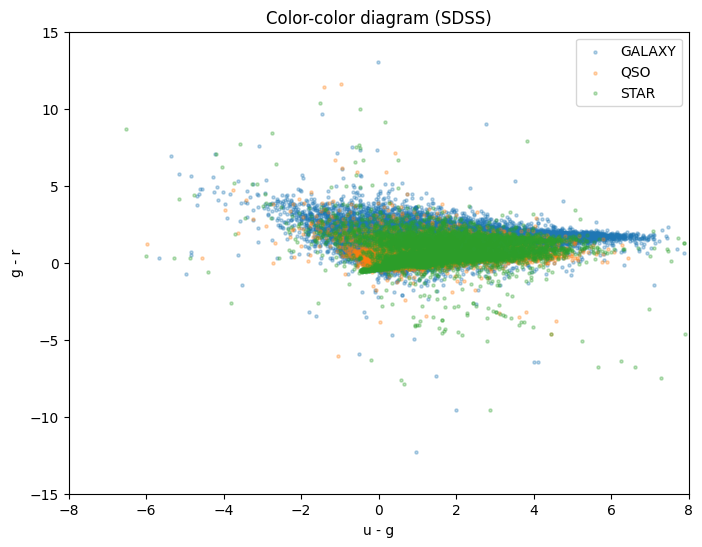

In [2]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]


print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

plt.figure(figsize=(8,6))

for c in star['class'].unique():
    subset = star[star['class'] == c]
    plt.scatter(subset['u_g'], subset['g_r'],
                label=c,
                s=5,
                alpha=0.3)
    plt.xlim(-8, 8)
    plt.ylim(-15, 15)

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.legend()
plt.title('Color-color diagram (SDSS)')
plt.show()



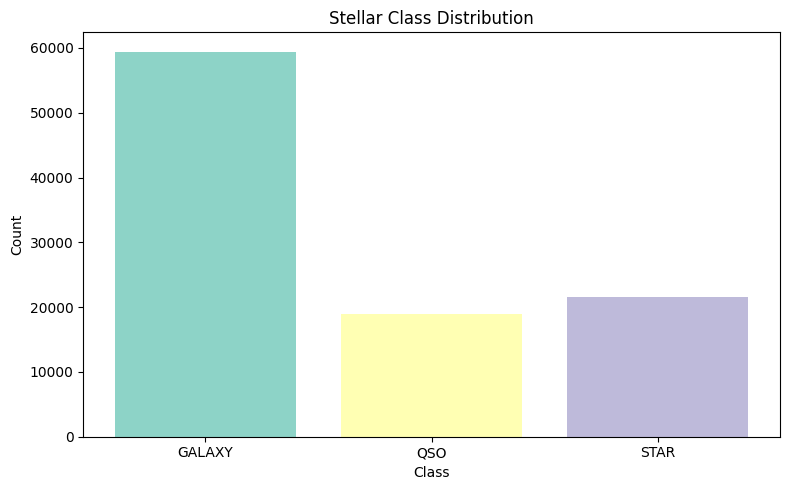

In [3]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [4]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

class_names = list(label_encoder.classes_)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print(feature_names)

Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'plate', 'MJD', 'u_g', 'g_r', 'r_i', 'i_z']


In [5]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)


print("DataLoaders created.")


DataLoaders created.


## Random Forest and Extra Trees 

In [6]:
import importlib, sys
to_remove = [k for k in sys.modules if 'stellar_classification' in k]
for k in to_remove:
    del sys.modules[k]
import stellar_classification as sc

In [7]:
#train su random forest ed extra trees
models = sc.train_trees_with_tuning(X_train, y_train, X_val, y_val, n_iter=5, cv=3)
rf_model = models['Random Forest']
et_model = models['Extra Trees']

Random Forest best params: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'log2', 'max_depth': 15}
  [Train] Acc=93.33%  F1=0.9333
  [Val] Acc=90.11%  F1=0.8743
Extra Trees best params: {'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None}
  [Train] Acc=95.09%  F1=0.9509
  [Val] Acc=90.20%  F1=0.8753


In [8]:
#evaluate test set
rf_metrics = sc.evaluate_test_set(y_test, rf_model.predict(X_test), 'Random Forest')
et_metrics = sc.evaluate_test_set(y_test, et_model.predict(X_test), 'Extra Trees')

sc.print_metrics(rf_metrics)
sc.print_metrics(et_metrics)


Random Forest:
  Accuracy  : 90.27%
  Precision: 0.8725
  Recall   : 0.8812
  F1       : 0.8760
  Confusion Matrix:
[[10117   381   283]
 [  207  3120   221]
 [  270   414  3244]]

Extra Trees:
  Accuracy  : 90.44%
  Precision: 0.8752
  Recall   : 0.8815
  F1       : 0.8775
  Confusion Matrix:
[[10159   368   254]
 [  209  3119   220]
 [  281   414  3233]]


KeyboardInterrupt: 

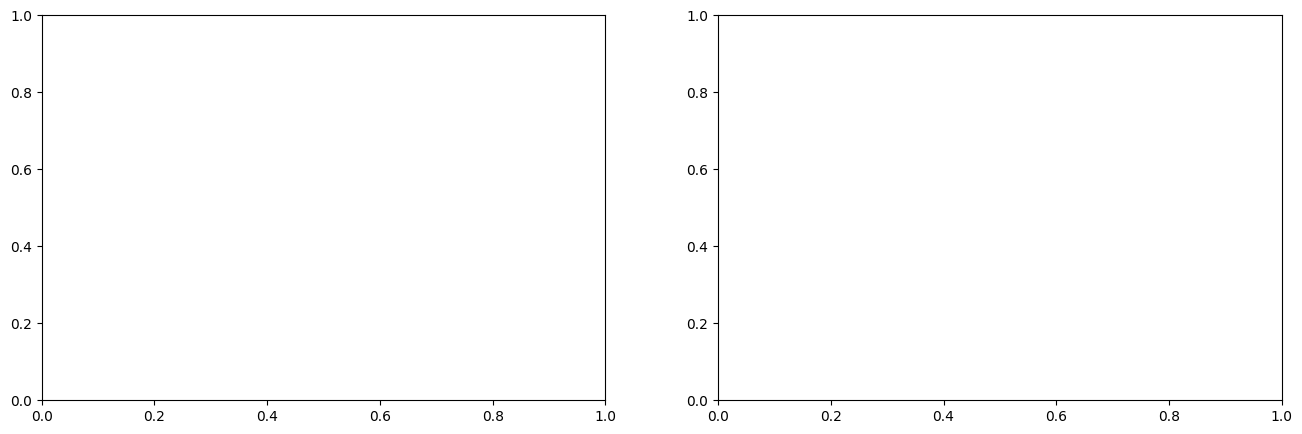

In [9]:
from stellar_classification.models.trees import SimpleRandomForest, SimpleExtraTrees

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc.plot_learning_curve(
    SimpleRandomForest(**rf_model.get_params()),
    X_train, y_train,
    title='Learning Curve — Random Forest',
    ax=axes[0]
)

sc.plot_learning_curve(
    SimpleExtraTrees(**et_model.get_params()),
    X_train, y_train,
    title='Learning Curve — Extra Trees',
    ax=axes[1]
)

plt.tight_layout()
plt.show()


se le curve iniziano a convergere significa che ipoteticamente l'overfitting è dovuto ad una insufficienza di dati. Ed è il caso in cui ci troviamo. Se cosi non fosse invece, allora l'overfitting sarebbe causato da una complessità del modello, possiamo quindi concludere che l'overfitting non è puramente strutturale.

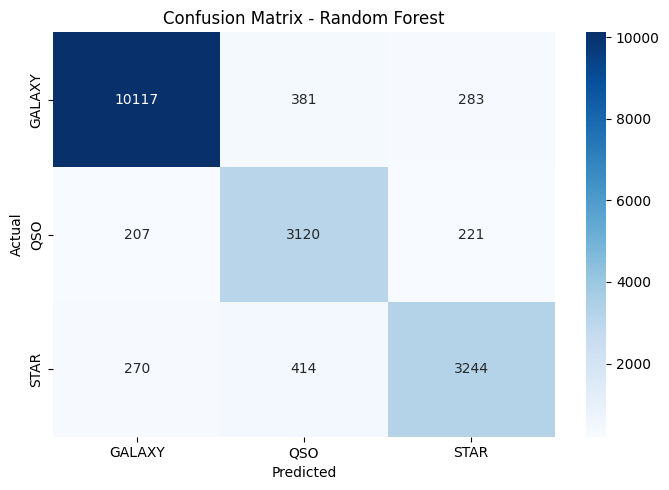

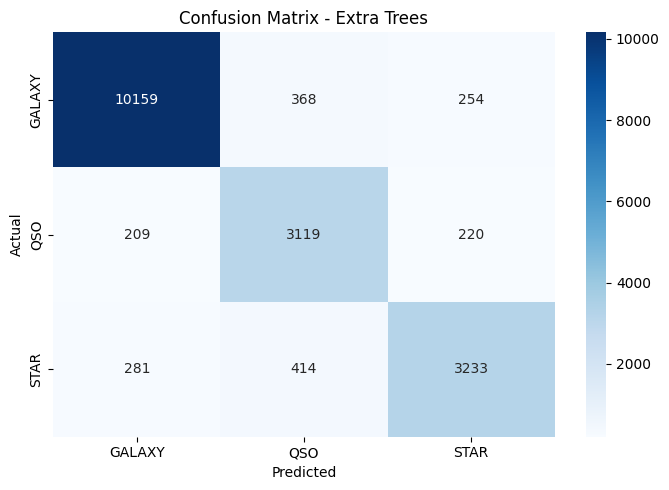

In [10]:
#matrici di confusione per i due modelli 

sc.plot_confusion_matrix(rf_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Random Forest')
sc.plot_confusion_matrix(et_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Extra Trees')

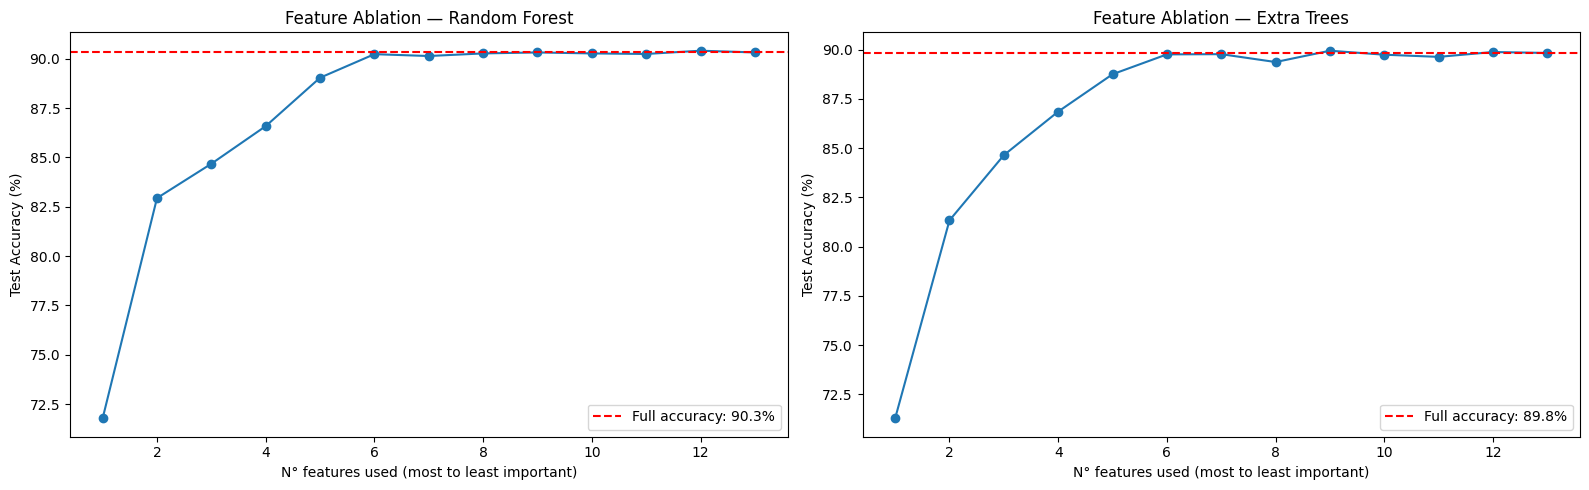

In [11]:
# Feature Ablation

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc.plot_feature_ablation(rf_model, X_train, X_test, y_train, y_test,
                         feature_names, 
                         title='Feature Ablation — Random Forest',
                         ax=axes[0])

sc.plot_feature_ablation(et_model, X_train, X_test, y_train, y_test,
                         feature_names,
                         title='Feature Ablation — Extra Trees',
                         ax=axes[1])

plt.tight_layout()
plt.show()

           RANDOM FOREST — Prediction & Error Map


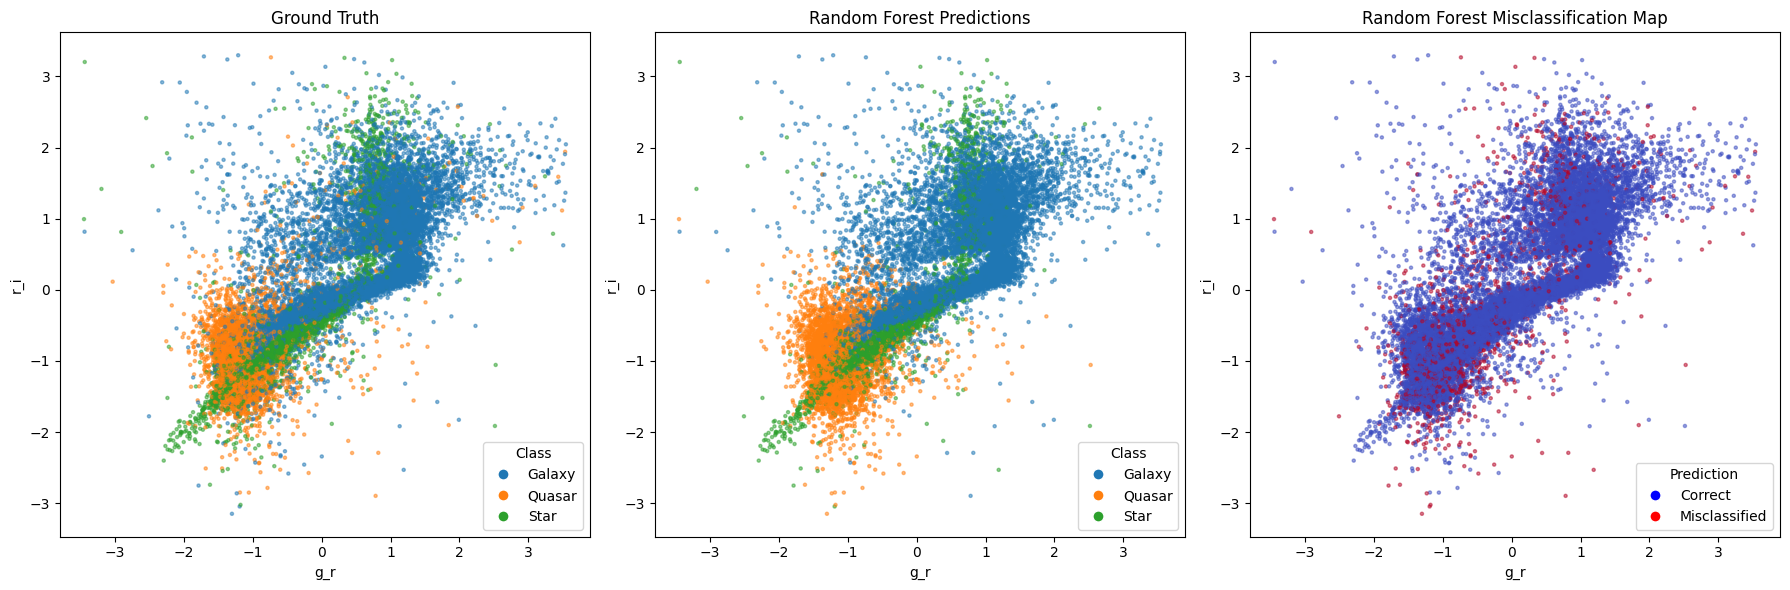

           EXTRA TREES — Prediction & Error Map


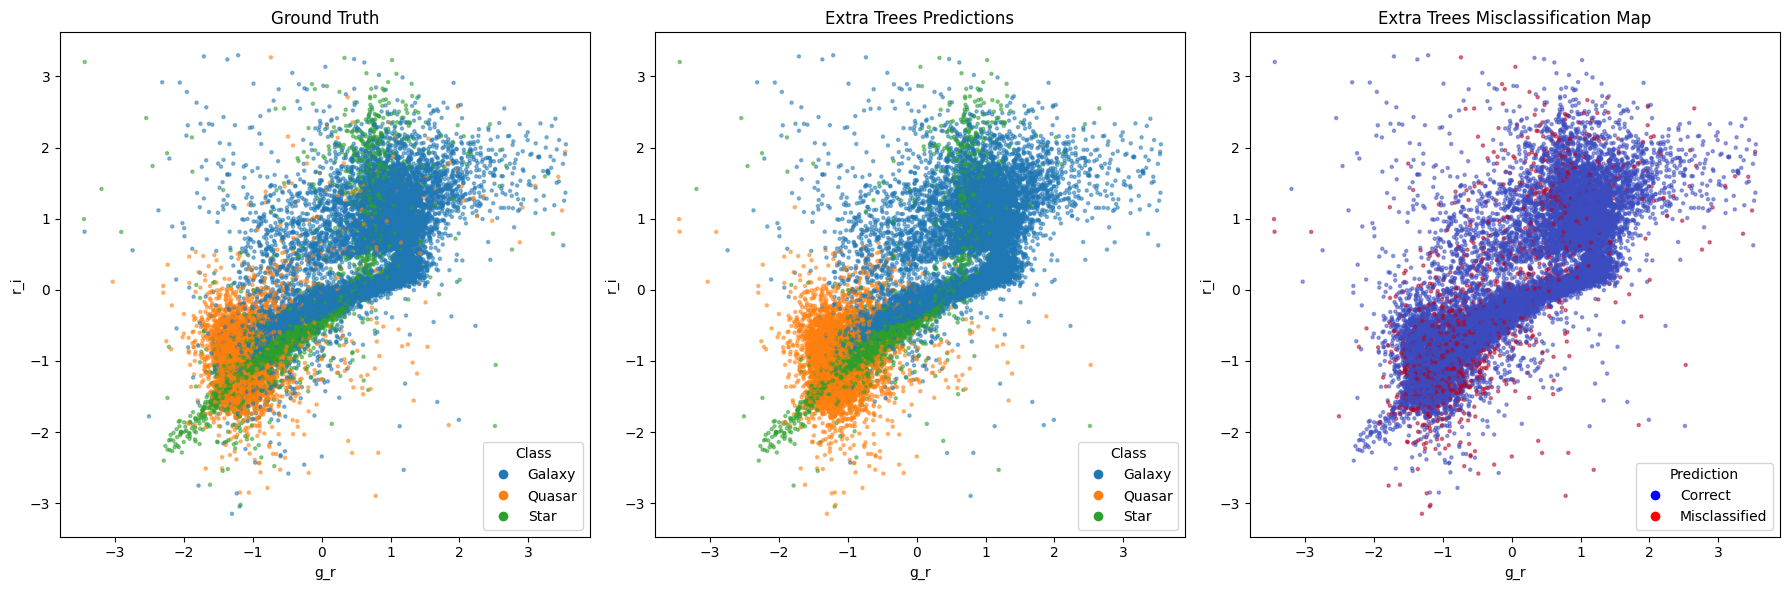

In [12]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)

y_test_pred_rf = rf_model.predict(X_test)
y_test_pred_et = et_model.predict(X_test)

print("           RANDOM FOREST — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_rf,
    feature_x="g_r", feature_y="r_i",
    title_prefix="Random Forest"
)
print("           EXTRA TREES — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_et,
    feature_x="g_r", feature_y="r_i",
    title_prefix="Extra Trees"
)

           RANDOM FOREST — Prediction & Error Map


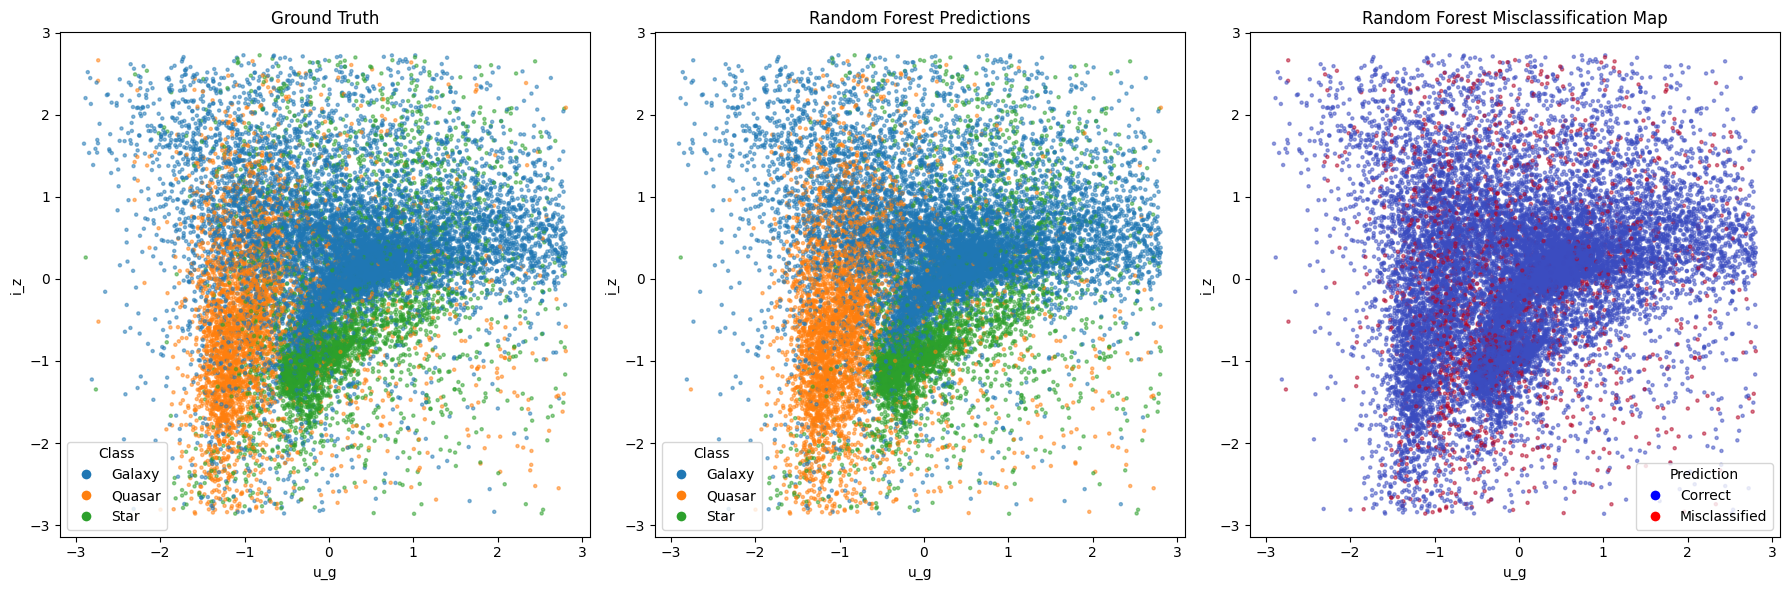

           EXTRA TREES — Prediction & Error Map


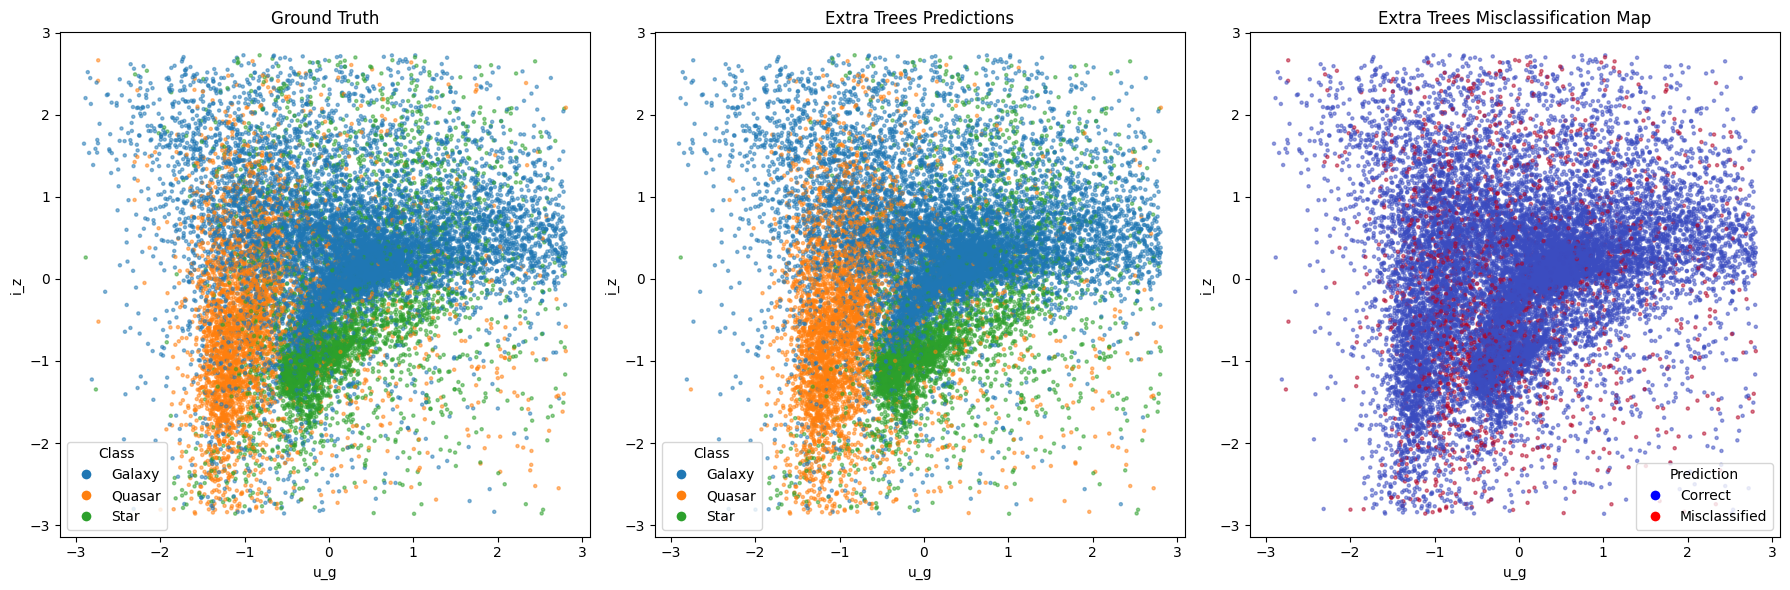

In [13]:
print("           RANDOM FOREST — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_rf,
    feature_x="u_g", feature_y="i_z",
    title_prefix="Random Forest"
)
print("           EXTRA TREES — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_et,
    feature_x="u_g", feature_y="i_z",
    title_prefix="Extra Trees"
)

           RANDOM FOREST 


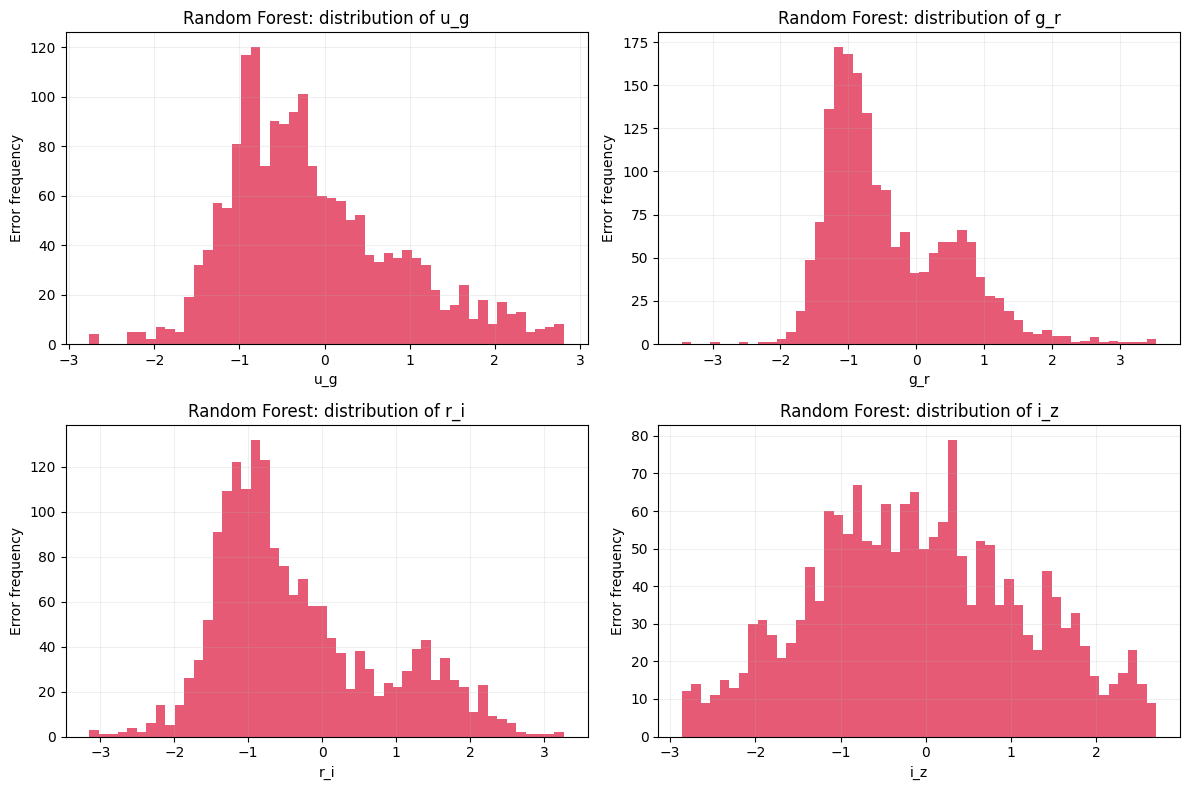

           EXTRA TREES 


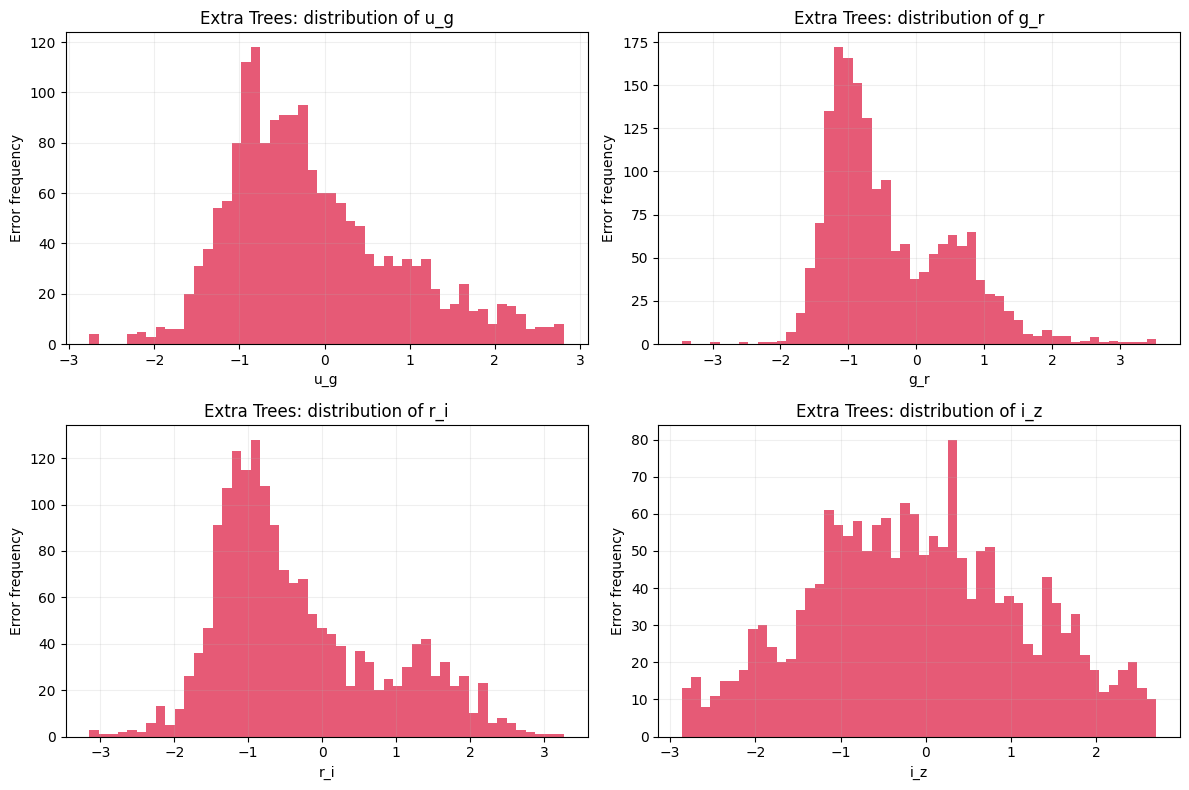

In [14]:
print("           RANDOM FOREST ")
sc.plot_misclassified_feature_distributions(
    X_test_df, y_test, y_test_pred_rf,
    features=["u_g", "g_r", "r_i", "i_z"],
    title_prefix="Random Forest"
)

print("           EXTRA TREES ")
sc.plot_misclassified_feature_distributions(
    X_test_df, y_test, y_test_pred_et,
    features=["u_g", "g_r", "r_i", "i_z"],
    title_prefix="Extra Trees"
)

           RANDOM FOREST — Feature Importance


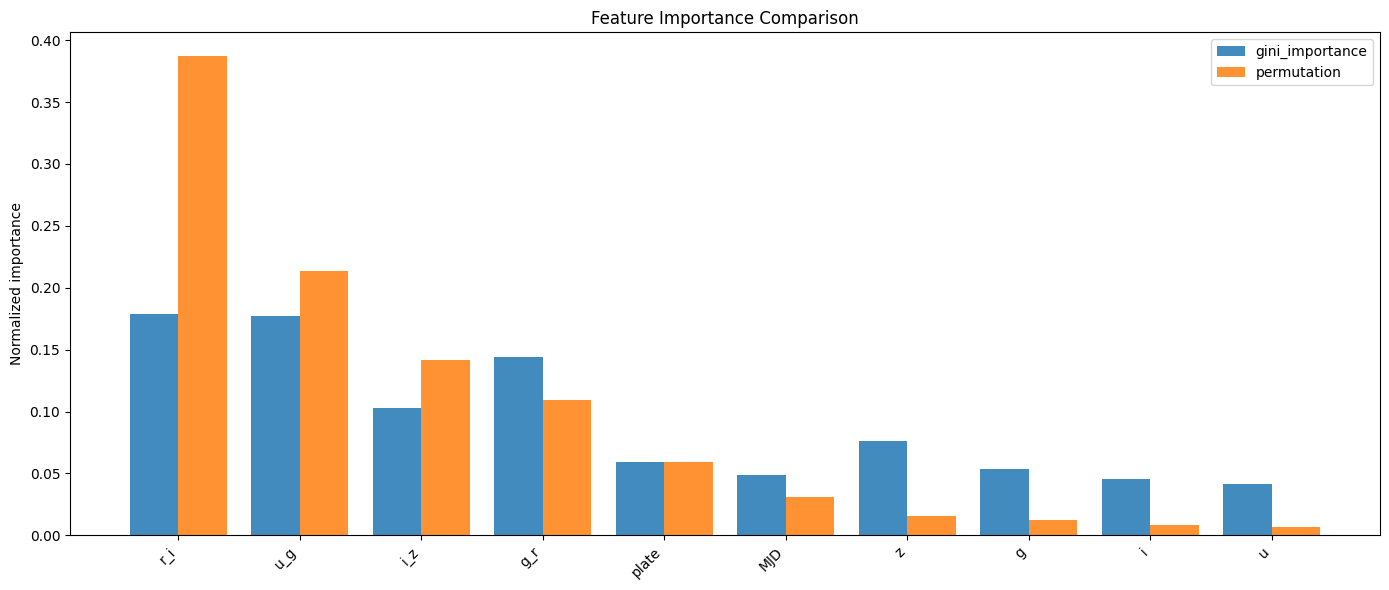


 Feature Importance Scores:


,gini_importance,permutation
r_i,0.178757,0.386959
u_g,0.176890,0.213720
i_z,0.102922,0.141592
g_r,0.143764,0.109555
plate,0.059233,0.059182
MJD,0.048788,0.030844
z,0.076151,0.015270
g,0.053402,0.012593
i,0.045893,0.008517
u,0.041375,0.006376


           EXTRA TREES — Feature Importance


In [ ]:
importance_functions= {
    "gini_importance": lambda m: m.feature_importances_
}



print("           RANDOM FOREST — Feature Importance")
df_imp_rf = sc.plot_feature_importance(
    rf_model,
    feature_names,
    importance_functions=importance_functions,
    
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    
    top_k=10,
    sort_by="permutation"
)



print("           EXTRA TREES — Feature Importance")
df_imp_et = sc.plot_feature_importance(
    et_model,
    feature_names,
    importance_functions=importance_functions,
    
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    
    top_k=10,
    sort_by="permutation"
)

## XGBoost and LightGBM

In [6]:
#hyperparameter tuning xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=3)

params = {"n_estimators": [300,500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb, best_params_xgb, best_score_xgb = sc.tune_model(
    xgb,
    params,
    X_train,
    y_train,
)

print("Best Hyperparameters:", best_params_xgb)

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [7]:
#xgboost training

best_params_xgb.pop("n_estimators", None)
best_params_xgb.pop("max_depth", None)

xgb_final = XGBClassifier(**best_params_xgb,n_estimators=1000,max_depth=3, objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42)
xgb_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],verbose=False)

train_metrics_xgb, val_metrics_xgb = sc.evaluate_single_model(
    xgb_final,
    X_train, y_train,
    X_val, y_val,
    model_name="XGBoost Tuned"
)

y_test_pred_xgb = xgb_final.predict(X_test)
xgb_metrics = sc.evaluate_test_set(y_test, y_test_pred_xgb, "XGBoost")
sc.print_metrics(xgb_metrics)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

[Training] Acc=91.3462% P=0.9136 R=0.9135 F1=0.9133
Confusion Matrix:
[[30560   929   855]
 [ 1602 29191  1551]
 [ 1268  2192 28884]]

[Validation] Acc=90.2120% P=0.8713 R=0.8797 F1=0.8749
Confusion Matrix:
[[10122   368   291]
 [  213  3088   247]
 [  268   400  3260]]


XGBoost:
  Accuracy  : 90.41%
  Precision: 0.8731
  Recall   : 0.8823
  F1       : 0.8773
  Confusion Matrix:
[[10129   366   286]
 [  219  3073   256]
 [  239   385  3304]]


In [8]:
#hyperparameter tuning lgbm

import os
os.environ["LIGHTGBM_VERBOSITY"] = "-1"
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_jobs=3,verbose=-1)
params = {"n_estimators": [300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "num_leaves": [15, 31], 
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10], 
  } 
   
best_model_lgbm, best_params_lgbm, best_score_lgbm = sc.tune_model(
    lgbm,
    params,
    X_train,
    y_train,verbose=False
)

print("Best Hyperparameters:", best_params_lgbm)

 

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'num_leaves': 31, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [9]:
#lgbm training

best_params_lgbm.pop("n_estimators", None)
best_params_lgbm.pop("max_depth", None)
lgbm_final = LGBMClassifier(**best_params_lgbm,n_estimators=1000,max_depth=3,verbose=-1 )

import lightgbm as lgb
lgbm_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],  eval_metric='multi_logloss',  callbacks=[lgb.early_stopping(50)])

train_metrics_lgbm, val_metrics_lgbm = sc.evaluate_single_model(
    lgbm_final,
    X_train, y_train,
    X_val, y_val,
    model_name="LightGBM Tuned"
)

y_test_pred_lgbm = lgbm_final.predict(X_test)
lgbm_metrics = sc.evaluate_test_set(y_test, y_test_pred_lgbm, "LightGBM")
sc.print_metrics(lgbm_metrics)

X_test_df = pd.DataFrame(X_test, columns=feature_names)



Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[990]	valid_0's multi_logloss: 0.290654
[Training] Acc=91.6759% P=0.9168 R=0.9168 F1=0.9167
Confusion Matrix:
[[30627   930   787]
 [ 1576 29264  1504]
 [ 1174  2106 29064]]

[Validation] Acc=90.3215% P=0.8728 R=0.8802 F1=0.8759
Confusion Matrix:
[[10144   356   281]
 [  219  3081   248]
 [  264   399  3265]]


LightGBM:
  Accuracy  : 90.34%
  Precision: 0.8727
  Recall   : 0.8816
  F1       : 0.8767
  Confusion Matrix:
[[10122   367   292]
 [  226  3067   255]
 [  244   379  3305]]


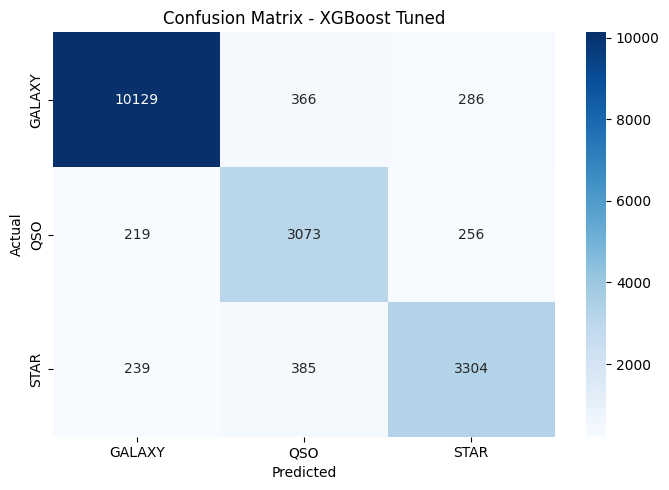

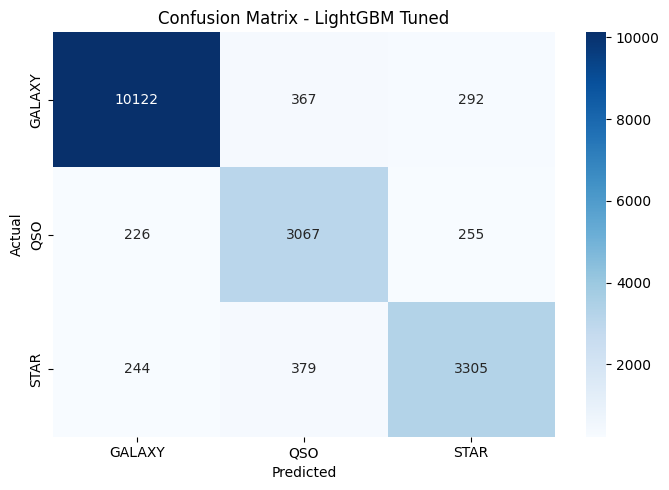

In [10]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(xgb_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - XGBoost Tuned')

sc.plot_confusion_matrix(lgbm_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - LightGBM Tuned')


SHAP summary for class: GALAXY


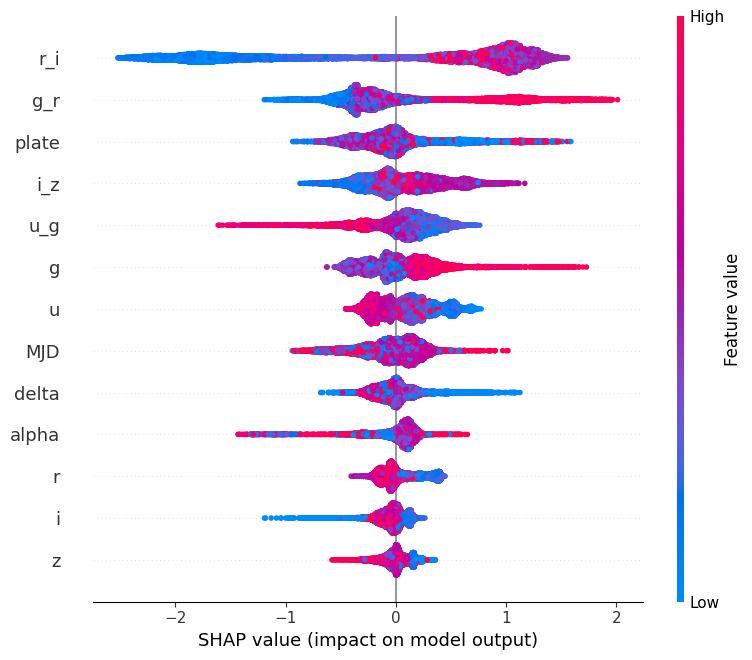


SHAP summary for class: QSO


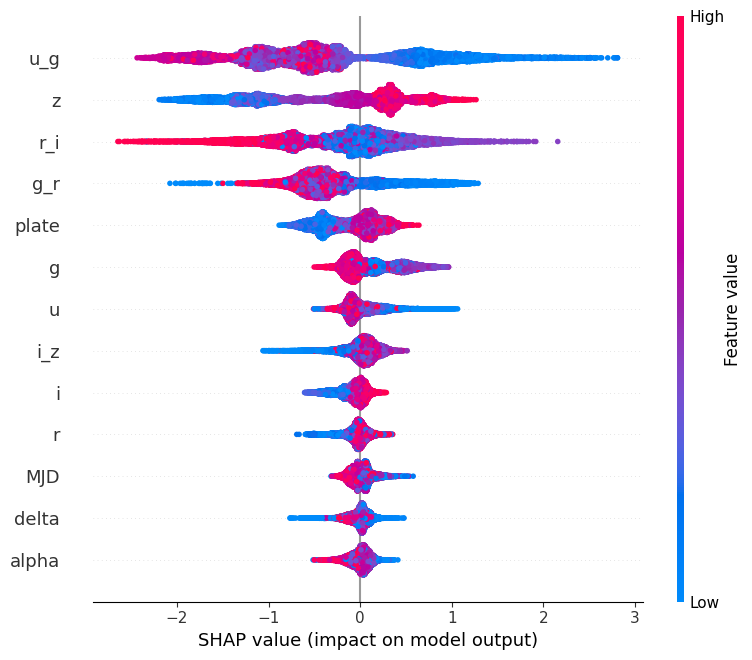


SHAP summary for class: STAR


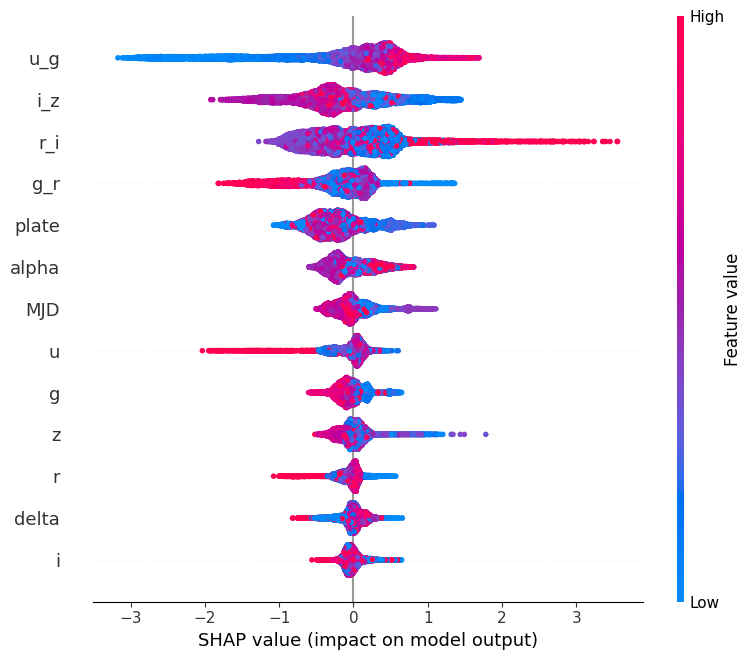

In [ ]:
#shap xgboost
shap_values_xgb = sc.shap_summary_tree_model(
    model=xgb_final,
    X=X_test,
    feature_names=feature_names,
    class_names=label_encoder.classes_
)


In [ ]:
#shap lightgbm
shap_values_lgbm = sc.shap_summary_tree_model(
    model=lgbm_final,
    X=X_test,
    feature_names=feature_names,
    class_names=label_encoder.classes_
)


SHAP summary for class: GALAXY


In [ ]:
print("          XGBoost — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="XGBoost"
)


print("            LightGBM — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="LightGBM"
)

In [ ]:
print("          XGBoost — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="u_g",
    feature_y="i_z",
    title_prefix="XGBoost")


print("            LightGBM — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    feature_x="u_g",
    feature_y="i_z",
    title_prefix="LightGBM")



In [ ]:
sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"]
)

sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    features=["u_g", "g_r", "r_i", "i_z"]
)

In [ ]:
results_xgb = sc.predict_with_confidence(
    model=xgb_final,
    X_test=X_test,
    X_plot=X_test_df,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="XGBoost",
    threshold=0.9,
)

final_pred_xgb = results_xgb["final_predictions"]
confidence_xgb = results_xgb["confidence"]



results_lgbm = sc.predict_with_confidence(
    model=lgbm_final,
    X_test=X_test,
    X_plot=X_test_df,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="LightGBM",
    threshold=0.9,
)

final_pred_lgbm = results_lgbm["final_predictions"]
confidence_lgbm = results_lgbm["confidence"]



In [ ]:
importance_functions_xgb = {

    "model_importance":
        lambda m: m.feature_importances_,

    "gain":
        lambda m: np.array([
            m.get_booster().get_score(
                importance_type="gain"
            ).get(f"f{i}", 0)
            for i in range(len(feature_names))
        ]),

    "weight":
        lambda m: np.array([
            m.get_booster().get_score(
                importance_type="weight"
            ).get(f"f{i}", 0)
            for i in range(len(feature_names))
        ])
}

df_imp = sc.plot_feature_importance(
    xgb_final,
    feature_names,
    prefix_name="XGBoost",

    importance_functions=importance_functions_xgb,

    use_permutation=True,
    X_test=X_test,
    y_test=y_test,

    top_k=15,
    sort_by="permutation"
)


importance_functions_lgbm = {

    # sklearn-style importance
    "model_importance":
        lambda m: m.feature_importances_,

    # numero split
    "split":
        lambda m: m.booster_.feature_importance(
            importance_type="split"
        ),

    # gain totale
    "gain":
        lambda m: m.booster_.feature_importance(
            importance_type="gain"
        )
}

df_imp = sc.plot_feature_importance(
    lgbm_final,
    feature_names,
    prefix_name="LightGBM",

    importance_functions=importance_functions_lgbm,

    use_permutation=True,
    X_test=X_test,
    y_test=y_test,

    top_k=15,
    sort_by="permutation"
)

In [ ]:
xgb_lc = XGBClassifier(**xgb_final.get_params())

# removed early stopping
xgb_lc.set_params(early_stopping_rounds=None)

sc.plot_learning_curve(
    xgb_lc,
    X_train,
    y_train
)




lgbm_lc = LGBMClassifier(**lgbm_final.get_params())

# removed early stopping
lgbm_lc.set_params(early_stopping_rounds=None)

sc.plot_learning_curve(
    lgbm_lc,
    X_train,
    y_train
)




In [ ]:
#feature ablation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

xgb_ablation = XGBClassifier(
    n_estimators=1000,   
    max_depth=xgb_final.max_depth,
    learning_rate=xgb_final.learning_rate,
    subsample=xgb_final.subsample,
    colsample_bytree=xgb_final.colsample_bytree,
    random_state=42
)
xgb_ablation.fit(X_train, y_train)
sc.plot_feature_ablation(xgb_ablation, X_train, X_test, y_train, y_test,
                         feature_names, 
                         title='Feature Ablation — XGBoost',
                         ax=axes[0])


lgbm_ablation = LGBMClassifier(
    n_estimators=1000,
    max_depth=lgbm_final.max_depth,
    learning_rate=lgbm_final.learning_rate,
    subsample=lgbm_final.subsample,
    colsample_bytree=lgbm_final.colsample_bytree,
    reg_alpha=lgbm_final.reg_alpha,
    reg_lambda=lgbm_final.reg_lambda,
)
lgbm_ablation.fit(X_train, y_train)
sc.plot_feature_ablation(lgbm_ablation, X_train, X_test, y_train, y_test,
                         feature_names,
                         title='Feature Ablation — LightGBM',
                         ax=axes[1])

axes[0].set_ylim(50, 100)
axes[1].set_ylim(50, 100)
plt.tight_layout()
plt.show()